<div style="background:linear-gradient(135deg,#0f2027 0%,#203a43 50%,#2c5364 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🎯&nbsp; Sampling & Metrics</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">Where you place collocation points and how you measure error are two quiet decisions that make or break a PINN. This notebook visualises sampling strategies and the library's error-metrics utilities.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#1e9e54;color:#fff;padding:4px 8px;">beginner</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">sampling · metrics</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">seconds · CPU</span></span></div>

A PINN only "sees" the PDE at the points where we evaluate the residual. **Space-filling** samples
give uniform coverage; **adaptive** samples concentrate effort where the equation is hard. And once
trained, we need honest **metrics** to know how good the solution is.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup</a></li>
  <li style="margin:3px 0;"><a href="#why" style="color:#1a73e8;text-decoration:none;">2 · Why Sampling Matters</a></li>
  <li style="margin:3px 0;"><a href="#lhs" style="color:#1a73e8;text-decoration:none;">3 · Latin-Hypercube vs Uniform</a></li>
  <li style="margin:3px 0;"><a href="#density" style="color:#1a73e8;text-decoration:none;">4 · Adaptive (Residual-Weighted) Sampling</a></li>
  <li style="margin:3px 0;"><a href="#metrics" style="color:#1a73e8;text-decoration:none;">5 · Measuring Error</a></li>
  <li style="margin:3px 0;"><a href="#takeaways" style="color:#1a73e8;text-decoration:none;">6 · Takeaways</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinn version : 0.1.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


<a id="why"></a>

## 2 · Why Sampling Matters

<div style="background:#fdeef2;border-left:5px solid #d6336c;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>🔑 Key Idea.</b> With a fixed budget of collocation points, <b>coverage quality</b> directly limits how well the residual is minimised across the domain. Clumpy samples leave blind spots where the PDE is never enforced.
</div>

<a id="lhs"></a>

## 3 · Latin-Hypercube vs Uniform

Latin-Hypercube Sampling (LHS) stratifies each axis so points spread out far more evenly than i.i.d. uniform draws. The library exposes it via `create_lhs_sampler`.

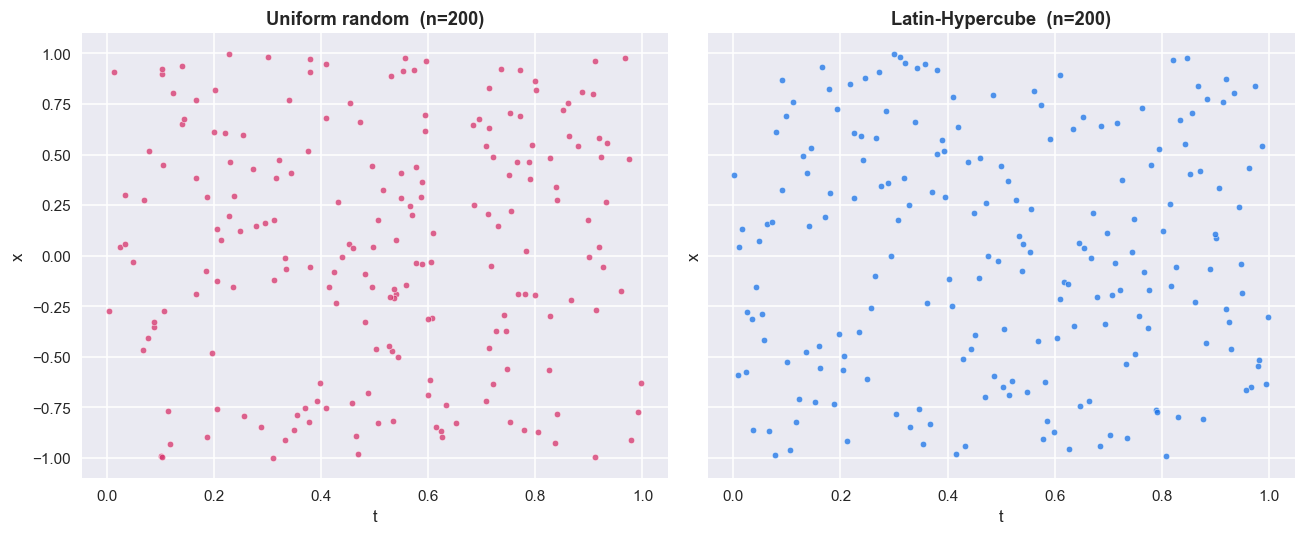

Uniform : mean NN-distance = 0.0512
LHS     : mean NN-distance = 0.0514


In [2]:
from pinnlab.sampling import create_lhs_sampler

bounds = [(0.0, 1.0), (-1.0, 1.0)]          # (t, x) domain
lhs = create_lhs_sampler(bounds, seed=SEED)
pts_lhs = lhs.sample(200)
pts_uni = np.column_stack([np.random.uniform(lo, hi, 200) for lo, hi in bounds])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, pts, name, col in zip(axes, [pts_uni, pts_lhs],
                              ["Uniform random", "Latin-Hypercube"], [ACCENT2, ACCENT]):
    ax.scatter(pts[:, 0], pts[:, 1], s=18, color=col, alpha=0.75, edgecolor="white", lw=0.4)
    ax.set(title=f"{name}  (n=200)", xlabel="t", ylabel="x")
plt.tight_layout(); plt.show()

# Quantify coverage by the largest nearest-neighbour gap (smaller = more even)
from scipy.spatial import cKDTree
for pts, name in [(pts_uni, "Uniform"), (pts_lhs, "LHS")]:
    d, _ = cKDTree(pts).query(pts, k=2)
    print(f"{name:8s}: mean NN-distance = {d[:, 1].mean():.4f}")

<div style="background:#e9f9ee;border-left:5px solid #1e9e54;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>✅ Tip.</b> LHS gives a more uniform spread for the same number of points — a free accuracy boost for forward problems.
</div>

<a id="density"></a>

## 4 · Adaptive (Residual-Weighted) Sampling

Smarter still: place *more* points where the PDE residual is large. Here we illustrate the idea by sampling proportionally to a synthetic 'difficulty' field that peaks near a front.

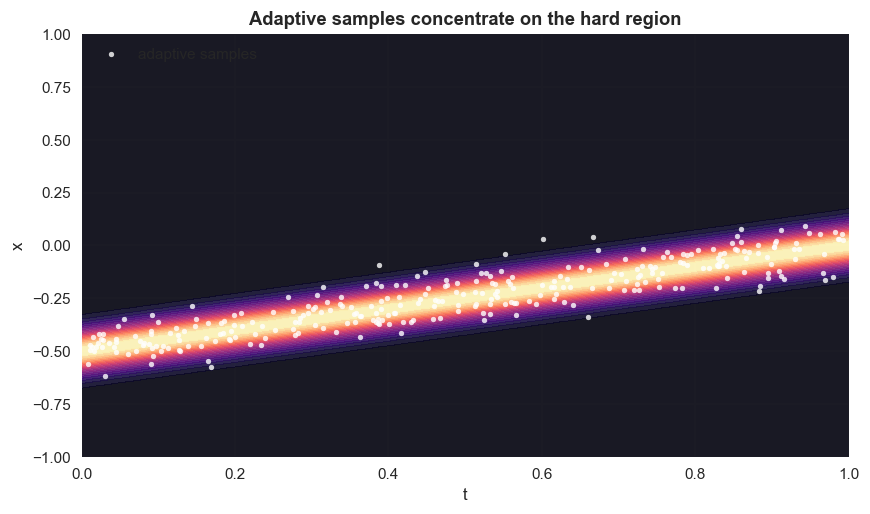

In [3]:
# A toy residual-magnitude field that is large near a moving front x ≈ 0.5 t
def difficulty(t, x):
    return np.exp(-((x - (0.5 * t - 0.5)) ** 2) / 0.01)

# Rejection-sample points with probability proportional to the difficulty
cand = np.column_stack([np.random.uniform(0, 1, 6000), np.random.uniform(-1, 1, 6000)])
w = difficulty(cand[:, 0], cand[:, 1]); w /= w.max()
keep = cand[np.random.uniform(size=len(cand)) < w][:300]

tt, xx = np.meshgrid(np.linspace(0, 1, 120), np.linspace(-1, 1, 120))
fig, ax = plt.subplots(figsize=(9, 5))
ax.contourf(tt, xx, difficulty(tt, xx), levels=20, cmap="magma", alpha=0.9)
ax.scatter(keep[:, 0], keep[:, 1], s=10, color="white", alpha=0.8, label="adaptive samples")
ax.set(title="Adaptive samples concentrate on the hard region", xlabel="t", ylabel="x")
ax.legend(loc="upper left"); plt.show()

<div style="background:#eaf2ff;border-left:5px solid #1a73e8;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>💡 Note.</b> The library automates this with <code>GradientBasedImportanceSampler</code> and the active-learning trainers — see <a href='benchmarks/01_active_learning_comparison.ipynb'>benchmarks/01_active_learning_comparison</a>.
</div>

<a id="metrics"></a>

## 5 · Measuring Error

`compute_error_metrics` returns a rich `ErrorMetrics` object: absolute and relative errors, norms, correlation, and R².

Error Metrics:
  MAE:           2.301706e-02
  RMSE:          2.861825e-02
  Max Error:     7.946711e-02
  Relative MAE:  9.358372e-02
  Relative RMSE: 3.001113e-01
  L2 Norm:       4.578920e-01
  L∞ Norm:       7.946711e-02
  Correlation:   0.999208
  R² Score:      0.998378


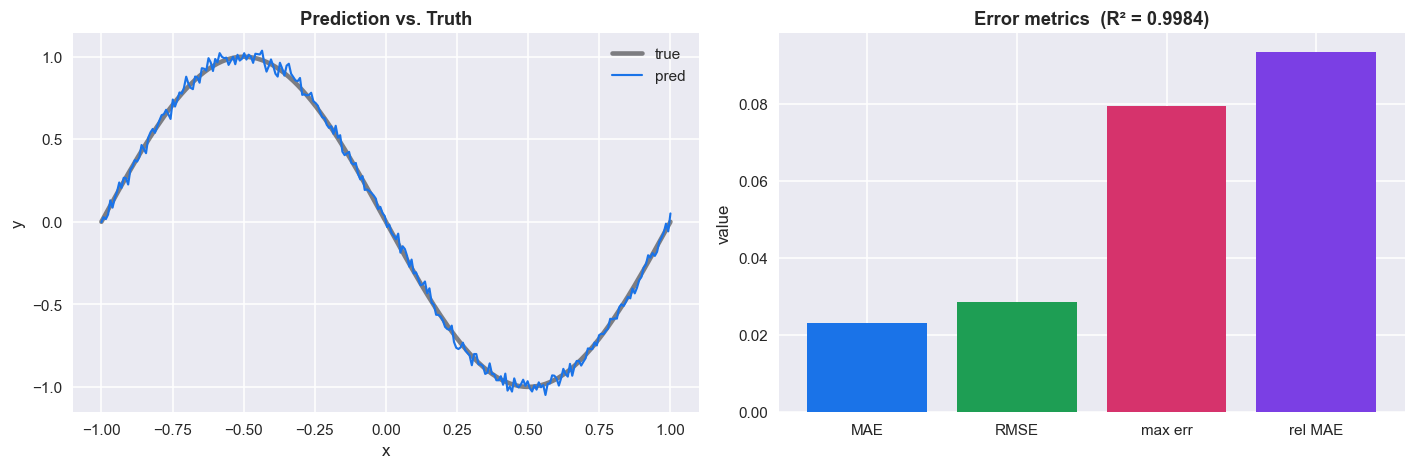

In [4]:
from pinnlab.utils.metrics import compute_error_metrics

x = np.linspace(-1, 1, 256)
y_true = -np.sin(np.pi * x)
y_pred = y_true + 0.03 * np.random.randn(x.size)      # pretend prediction

m = compute_error_metrics(y_pred, y_true)
print(m)                                              # pretty __str__

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
a1.plot(x, y_true, color="#111", lw=3, alpha=0.5, label="true")
a1.plot(x, y_pred, color=ACCENT, lw=1.4, label="pred")
a1.set(title="Prediction vs. Truth", xlabel="x", ylabel="y"); a1.legend()

names = ["MAE", "RMSE", "max err", "rel MAE"]
vals  = [m.mae, m.rmse, m.max_error, m.relative_mae]
a2.bar(names, vals, color=[ACCENT, ACCENT3, ACCENT2, "#7b3fe4"])
a2.set(title=f"Error metrics  (R² = {m.r2_score:.4f})", ylabel="value")
plt.tight_layout(); plt.show()

<a id="takeaways"></a>

## 6 · Takeaways

- **Latin-Hypercube** sampling spreads collocation points more evenly than uniform random draws for
  the same budget — use `create_lhs_sampler`.
- **Adaptive / importance** sampling concentrates points where the residual is large; the library
  provides this through `GradientBasedImportanceSampler` and the active-learning trainers.
- `compute_error_metrics` is your one-stop validation summary — absolute & relative errors, norms,
  correlation and R² — returned as a tidy `ErrorMetrics` object.

### 📚 References

1. McKay, M. D., Beckman, R. J., & Conover, W. J. (1979). *A comparison of three methods for selecting values of input variables*. Technometrics, 21(2), 239–245.
2. Lu, L. et al. (2021). *DeepXDE: A deep learning library for solving differential equations*. SIAM Review, 63(1), 208–228.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinn</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>